In [1]:
from exoatlas import * 
from exoatlas.visualizations import * 

In [2]:
e = TransitingExoplanets()
e.insolation(), e.insolation_uncertainty()

Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt


(<Quantity [3627577.07788034,   29608.87096836,   10158.54994587, ...,
             704037.87512649, 1878755.2672563 ,  425493.97571523] W / m2>,
 <Quantity [ 87018.50557987,   3671.8593202 ,   1177.88053897, ...,
            133432.98000009,  53009.89420249,  12026.03695002] W / m2>)

Saved a standardized text table to /Users/zabe0091/exoatlas-data/data/standardized-SolarSystem.txt
Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt


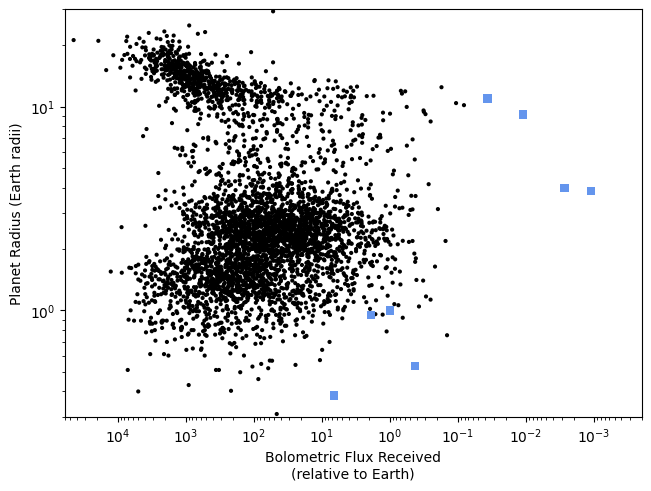

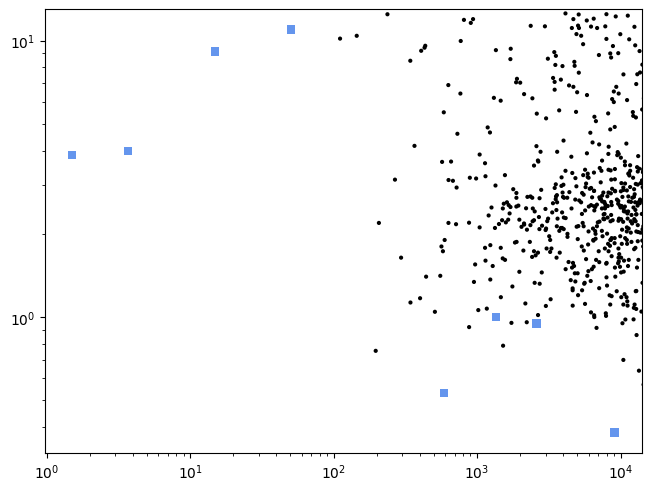

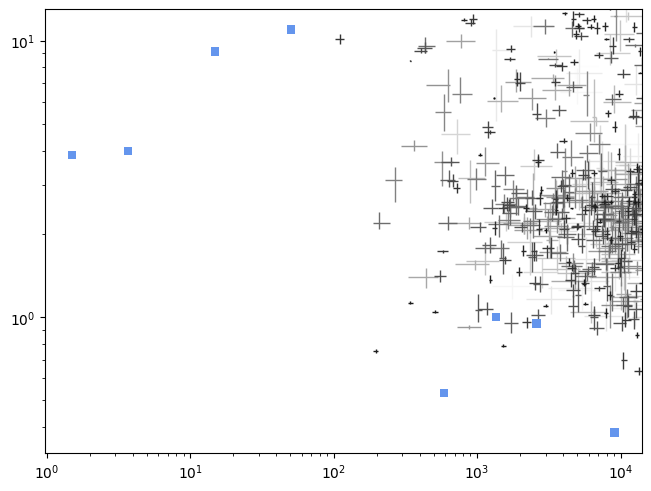

In [3]:
    pops = {}
    pops["solarsystem"] = SolarSystem()
    pops['exo'] = TransitingExoplanets()

    fr = Flux_x_Radius()
    fr.build(pops=pops)

    fr = BubblePanel(xaxis=Plottable(source="insolation"), yaxis=Plottable(source="radius"))
    fr.build(pops=pops)

    fr = ErrorPanel(xaxis=Plottable(source="insolation"), yaxis=Plottable(source="radius"))
    fr.build(pops=pops)

In [4]:
e = pops['exo']
e.insolation(distribution=True)


/Users/zabe0091/miniconda3/envs/exoatlas/lib/python3.13/site-packages/astropy/uncertainty/core.py:256: RuntimeWarning: invalid value encountered in power
  results = getattr(ufunc, method)(*converted, **kwargs)


<QuantityDistribution [[3631840.11902349, 3723160.30109066, 3695060.54551555, ...,
            3577667.75282393, 3530323.45267179, 3915097.39676924],
           [  24867.07642454,   30002.45353089,   23689.69125695, ...,
              24761.71832001,   30636.20340293,   31653.37778775],
           [  10772.61635473,   10600.58006553,    9788.41899477, ...,
              10806.10220429,   10943.55252926,   12216.58522941],
           ...,
           [ 519291.73859773,  630319.24520835,  722759.66407135, ...,
             788984.07601154,  751181.48609873,  702000.48794793],
           [1815383.9383669 , 1879312.60193904, 1863067.54822976, ...,
            1791822.26030622, 1844102.35857253, 1951378.8023106 ],
           [ 419734.91740348,  435321.88937254,  410315.18709864, ...,
             429373.10326878,  434218.91396838,  431539.4495317 ]] W / m2 with n_samples=100>

In [6]:
e.get_uncertainty_lowerupper('insolation')

(array([            nan,   3266.79951698,   1088.93317233, ...,
                    nan, 110254.48369809,  89836.98671697], shape=(4406,)),
 array([            nan,   3402.91616352,   1225.04981887, ...,
                    nan, 110254.48369809,  39473.82749685], shape=(4406,)))

In [ ]:
self = e 
key = 'insolation'
kw = {}
mu = self.get(key, **kw)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    f = self.targeted_fractional_uncertainty_precision
    total_number_of_samples = 1 / f**2
    number_of_iterations = int(
        np.maximum(
            np.ceil(
                total_number_of_samples
                / self._number_of_uncertainty_samples
            ),
            1,
        )
    )

    sigma_lowers, sigma_uppers = [], []
    for i in range(number_of_iterations):
        d = self.get(key, distribution=True, **kw)
        # calculate uncertainties from percentiles if possible...
        if isinstance(d, Distribution):
            lower, upper = d.pdf_percentiles(
                100
                * np.array(
                    [
                        0.5 - gaussian_central_1sigma / 2,
                        0.5 + gaussian_central_1sigma / 2,
                    ]
                )
            )
            sigma_lower, sigma_upper = mu - lower, upper - mu
        # ...otherwise just force the uncertainties to zero
        else:
            sigma_lower, sigma_upper = 0 * mu, 0 * mu
        sigma_lowers.append(sigma_lower)
        sigma_uppers.append(sigma_upper)
    average_sigma_lower = np.mean(u.Quantity(sigma_lowers), axis=0)
    average_sigma_upper = np.mean(u.Quantity(sigma_uppers), axis=0)

    def replace_negative(x):
        bad = x < 0
        x[bad] = np.nan
        return x

replace_negative(average_sigma_lower), replace_negative(
        average_sigma_upper
    )

(<Quantity [ 84776.09184663,   3922.1986023 ,   1233.71530377, ...,
            115334.21661066,  56215.37958568,  10805.62110766] W / m2>,
 <Quantity [106173.4042338 ,   3834.84781621,   1354.59938517, ...,
            156368.84998626,  66454.00759981,  12211.5182875 ] W / m2>)

In [ ]:
e.get_uncertainty_lowerupper_from_table('insolation')

(array([            nan,   3266.79951698,   1088.93317233, ...,
                    nan, 110254.48369809,  89836.98671697], shape=(4406,)),
 array([            nan,   3402.91616352,   1225.04981887, ...,
                    nan, 110254.48369809,  39473.82749685], shape=(4406,)))

In [11]:
(u.Lsun / 4 / np.pi / (1 * u.AU) ** 2).to("W/m**2")

<Quantity 1361.16646541 W / m2>

In [ ]:
e.get_values_from_table('insolation')

array([             nan,   28856.72906666,    9936.51519748, ...,
                    nan, 2096196.35672921,  420600.43781125],
      shape=(4406,))

In [12]:
e.get_values_from_table('mass')

<Quantity [  7.99   ,  20.12   ,   9.6    , ...,       nan, 225.34147,
             4.3    ] earthMass>

In [6]:
average_sigma_lower

<Quantity [ 84776.09184663,   3922.1986023 ,   1233.71530377, ...,
           115334.21661066,  56215.37958568,  10805.62110766] W / m2>

In [7]:
replace_negative(average_sigma_lower)

<Quantity [ 84776.09184663,   3922.1986023 ,   1233.71530377, ...,
           115334.21661066,  56215.37958568,  10805.62110766] W / m2>

In [9]:
average_sigma_lower = np.mean(u.Quantity(sigma_lowers), axis=0)
average_sigma_lower

<Quantity [ 86238.94186174,   3232.76350174,   1335.29893297, ...,
           114441.20779002,  55074.64820909,  11002.97606838] W / m2>

In [ ]:
e.insolation_uncertainty_lower_upp()

(array([            nan,   3266.79951698,   1088.93317233, ...,
                    nan, 110254.48369809,  89836.98671697], shape=(4406,)),
 array([            nan,   3402.91616352,   1225.04981887, ...,
                    nan, 110254.48369809,  39473.82749685], shape=(4406,)))

In [ ]:
Plottable(source="insolation").uncertainty(pops['exo'])


array([             nan,    3334.85784025,    1156.9914956 , ...,
                    nan,  110254.48369809,   64655.40710691])

Loaded standardized table from /Users/zabe0091/exoatlas-data/data/standardized-Exoplanets.txt


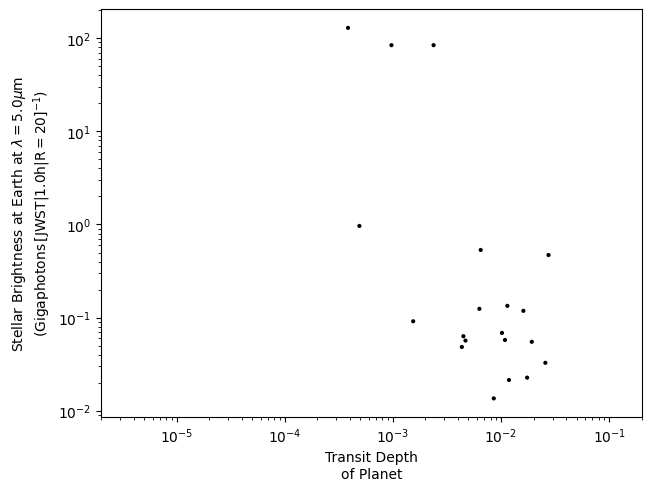

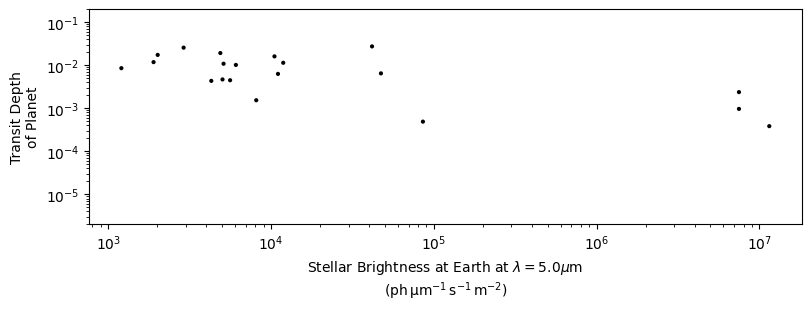

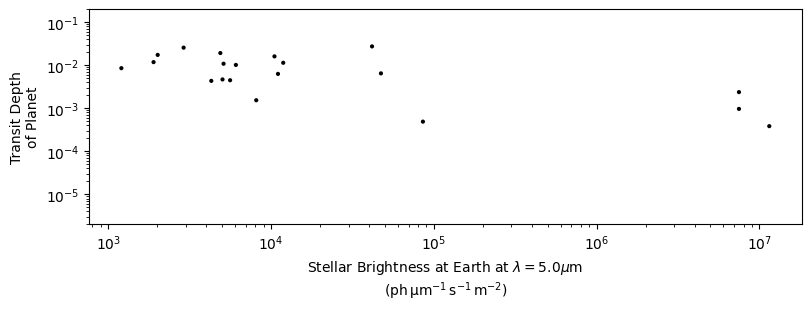

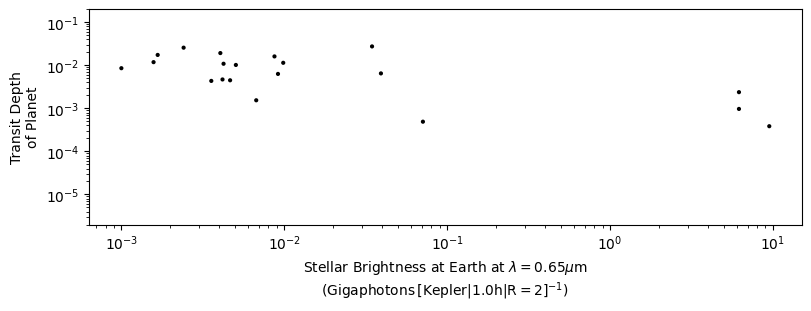

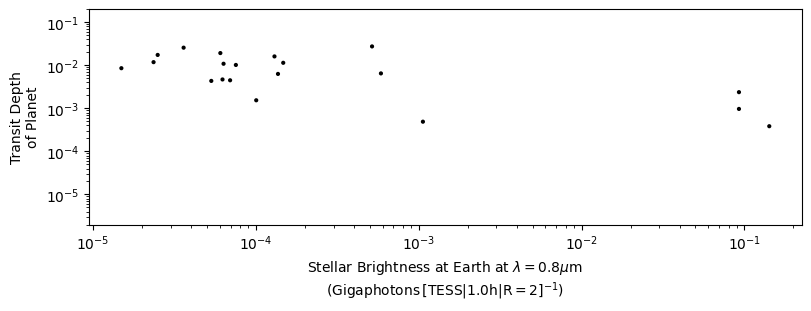

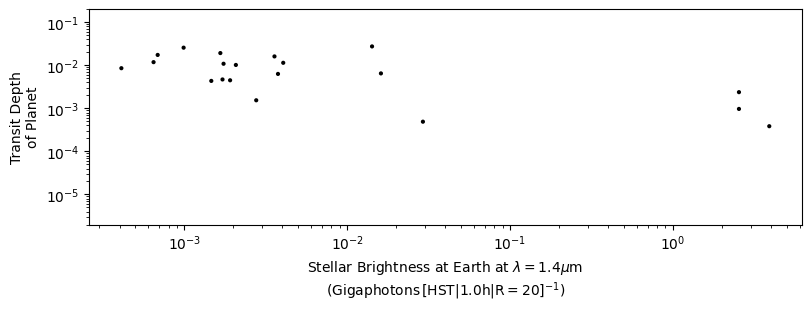

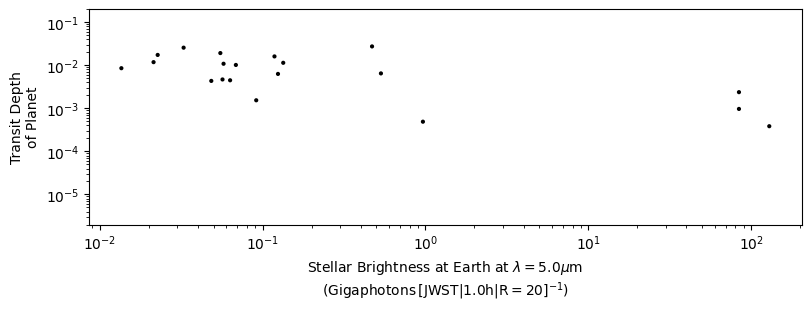

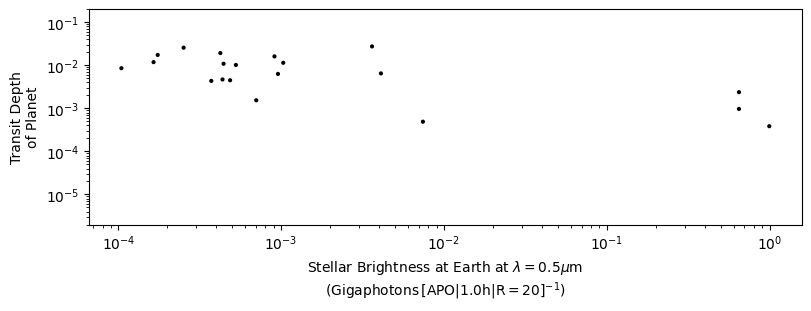

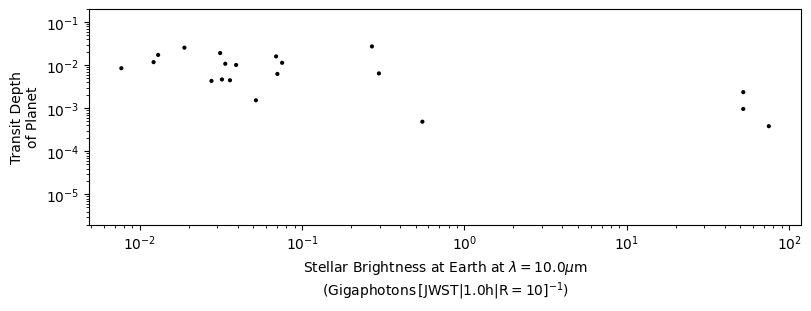

In [3]:
t = TransitingExoplanets()[:20]
Depth_x_Brightness().build([t])
BubblePanel(xaxis=StellarBrightness, yaxis=Depth).build([t])
BubblePanel(xaxis=StellarBrightness(wavelength=5 * u.micron), yaxis=Depth).build(
    [t]
)
for k in telescope_units:
    BubblePanel(
        xaxis=StellarBrightnessTelescope(telescope_name=k), yaxis=Depth
    ).build([t])
BubblePanel(
    xaxis=StellarBrightnessTelescope(
        telescope_name="JWST", wavelength=10 * u.micron, R=10
    ),
    yaxis=Depth,
).build([t])